**DDPM**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import math

In [ ]:
BATCH_SIZE = 64
EPOCHS = 2000
LR = 1e-4
IMG_SIZE = 64
NUM_CLASSES = 2
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs("images", exist_ok=True)

In [15]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder("newdata/train", transform=transform)
dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [16]:
T = 1000

beta = torch.linspace(1e-4, 0.02, T).to(DEVICE)
alpha = 1. - beta
alpha_hat = torch.cumprod(alpha, dim=0)

In [ ]:
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        emb = torch.exp(
            torch.arange(half_dim, device=device) * -(math.log(10000) / (half_dim - 1))
        )

        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)

        return self.mlp(emb)


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.norm1 = nn.GroupNorm(8, out_channels)
        self.norm2 = nn.GroupNorm(8, out_channels)

        self.emb_layer = nn.Linear(emb_dim, out_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = F.relu(h)

        emb_out = self.emb_layer(emb).unsqueeze(-1).unsqueeze(-1)
        h = h + emb_out

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.relu(h)

        return h + self.shortcut(x)


class Down(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.res = ResBlock(in_channels, out_channels, emb_dim)

    def forward(self, x, emb):
        x = self.pool(x)
        return self.res(x, emb)


class Up(nn.Module):
    def __init__(self, in_channels, out_channels, emb_dim):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.res = ResBlock(in_channels, out_channels, emb_dim)

    def forward(self, x1, x2, emb):
        x1 = self.up(x1)

        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        x = torch.cat([x2, x1], dim=1)
        return self.res(x, emb)


class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        emb_dim = 128

        # embedding
        self.time_emb = TimeEmbedding(emb_dim)
        self.label_emb = nn.Embedding(num_classes, emb_dim)

        # encoder
        self.inc = ResBlock(3, 64, emb_dim)
        self.down1 = Down(64, 128, emb_dim)
        self.down2 = Down(128, 256, emb_dim)
        self.down3 = Down(256, 512, emb_dim)  

        # bottleneck
        self.bot = ResBlock(512, 512, emb_dim)
        self.attn = nn.MultiheadAttention(embed_dim=512, num_heads=4, batch_first=True)

        # decoder
        self.up1 = Up(512 + 256, 256, emb_dim)
        self.up2 = Up(256 + 128, 128, emb_dim)
        self.up3 = Up(128 + 64, 64, emb_dim)

        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x, t, labels):
        t = t / 1000.0

        t_emb = self.time_emb(t)
        l_emb = self.label_emb(labels)

        emb = t_emb + 2 * l_emb

        # encoder
        x1 = self.inc(x, emb)
        x2 = self.down1(x1, emb)
        x3 = self.down2(x2, emb)
        x4 = self.down3(x3, emb)

        # bottleneck
        x5 = self.bot(x4, emb)

        b, c, h, w = x5.shape

        # flatten: (B, C, H, W) → (B, H*W, C)
        x_flat = x5.view(b, c, h*w).permute(0, 2, 1)

        # attention
        x_attn, _ = self.attn(x_flat, x_flat, x_flat)

        # reshape
        x_attn = x_attn.permute(0, 2, 1).view(b, c, h, w)

        # residual
        x5 = x5 + x_attn

        # decoder
        x = self.up1(x5, x3, emb)
        x = self.up2(x, x2, emb)
        x = self.up3(x, x1, emb)

        return self.outc(x)

In [18]:
model = UNet(NUM_CLASSES).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [19]:
def add_noise(x, t):
    noise = torch.randn_like(x)
    sqrt_alpha_hat = torch.sqrt(alpha_hat[t])[:, None, None, None]
    sqrt_one_minus = torch.sqrt(1 - alpha_hat[t])[:, None, None, None]
    return sqrt_alpha_hat * x + sqrt_one_minus * noise, noise

In [ ]:
def sample_images(epoch):
    model.eval()

    n = 5
    x = torch.randn(n, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    labels = torch.tensor([0,0,1,1,1]).to(DEVICE)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=DEVICE, dtype=torch.long)

        with torch.no_grad():
            predicted_noise = model(x, t_batch, labels)

        alpha_t = alpha[t]
        alpha_hat_t = alpha_hat[t]
        beta_t = beta[t]

        if t > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x)

        x = (1 / torch.sqrt(alpha_t)) * (
            x - ((1 - alpha_t) / torch.sqrt(1 - alpha_hat_t)) * predicted_noise
        ) + torch.sqrt(beta_t) * noise

    x = (x.clamp(-1,1) + 1) / 2

    fig, axs = plt.subplots(1, 5, figsize=(12,3))
    for i in range(5):
        img = x[i].cpu().permute(1,2,0).numpy()
        axs[i].imshow(img)
        axs[i].set_title(f"class {labels[i].item()}")
        axs[i].axis('off')

    plt.savefig(f"images/epoch_{epoch}.png")
    plt.close()

In [21]:
losses = []

for epoch in range(EPOCHS):
    for i, (imgs, labels) in enumerate(dataloader):

        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        t = torch.randint(0, T, (imgs.size(0),), device=DEVICE)

        noisy_imgs, noise = add_noise(imgs, t)

        optimizer.zero_grad()

        predicted_noise = model(noisy_imgs, t, labels)

        loss = criterion(predicted_noise, noise)
        loss.backward()
        optimizer.step()

    losses.append(loss.item())

    print(f"[Epoch {epoch}] Loss: {loss.item():.4f}")

    # ✅ 每50轮生成（完全保留你的习惯）
    if epoch % 50 == 0:
        sample_images(epoch)

[Epoch 0] Loss: 0.3622
[Epoch 1] Loss: 0.1036
[Epoch 2] Loss: 0.1025
[Epoch 3] Loss: 0.0793
[Epoch 4] Loss: 0.0350
[Epoch 5] Loss: 0.0250
[Epoch 6] Loss: 0.0432
[Epoch 7] Loss: 0.0282
[Epoch 8] Loss: 0.0258
[Epoch 9] Loss: 0.0541
[Epoch 10] Loss: 0.0357
[Epoch 11] Loss: 0.0209
[Epoch 12] Loss: 0.0212
[Epoch 13] Loss: 0.0207
[Epoch 14] Loss: 0.0288
[Epoch 15] Loss: 0.0320
[Epoch 16] Loss: 0.0170
[Epoch 17] Loss: 0.0224
[Epoch 18] Loss: 0.0117
[Epoch 19] Loss: 0.0298
[Epoch 20] Loss: 0.0235
[Epoch 21] Loss: 0.0320
[Epoch 22] Loss: 0.0271
[Epoch 23] Loss: 0.0291
[Epoch 24] Loss: 0.0259
[Epoch 25] Loss: 0.0142
[Epoch 26] Loss: 0.0342
[Epoch 27] Loss: 0.0170
[Epoch 28] Loss: 0.0216
[Epoch 29] Loss: 0.0220
[Epoch 30] Loss: 0.0211
[Epoch 31] Loss: 0.0423
[Epoch 32] Loss: 0.0326
[Epoch 33] Loss: 0.0272
[Epoch 34] Loss: 0.0202
[Epoch 35] Loss: 0.0312
[Epoch 36] Loss: 0.0127
[Epoch 37] Loss: 0.0247
[Epoch 38] Loss: 0.0319
[Epoch 39] Loss: 0.0341
[Epoch 40] Loss: 0.0131
[Epoch 41] Loss: 0.0155
[E

In [22]:
def plot_losses(losses):
    plt.figure(figsize=(8,5))

    plt.plot(losses, label="DDPM Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve")
    plt.legend()
    plt.grid()

    plt.savefig("images/loss_curve.png")
    plt.show()

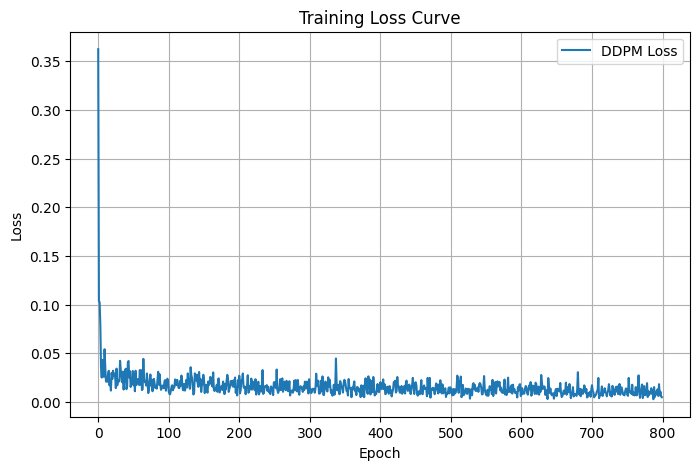

In [23]:
plot_losses(losses)

In [24]:
torch.save(model.state_dict(), "ddpm_1000epoch.pth")